# 08 – Bias and Fairness Audit 

**Answers part of sub-question 4**: *What ethical and societal implications arise from deploying such a system — particularly concerning fairness across vehicle types and road-user categories?*

## What this audit does

Slices the conformal detector's performance across five potential sources of bias and asks whether performance is stable across subgroups. The five slices:

1. **Vehicle type** (car vs truck/bus). Trucks have fundamentally different kinematics (longer braking distances, lower max acceleration).
2. **Time of day** (morning peak / midday / evening peak / night). Driver populations and behaviours differ by time.
3. **Entry/exit corridor (cluster)**. Trajectories in tiny clusters have less training support, so the detector's calibration may be worse there. 
4. **Time in the conflict zone**. The detector uses rolling-window features that need ~1-2 seconds of history. 
5. **Imputed-row contamination** (`accel_from_estimated`). Roughly 13% of rows have positions imputed by the Viscando tracker. 

## Outputs

- A summary table per slice, comparing Variant A's performance across subgroups at a fixed ε.
- Plots showing how FA rate, recall, and flag rate vary across each slice.
- A short narrative summarising where bias *was* and *was not* found, ready to lift into the thesis ethics chapter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Parameters and load

Loads the scored features file produced by notebook 06 (which contains the conformal p-values per row for Variant A and per trajectory for Variant B). All analysis is on the **test split only**.

In [2]:
IN_PATH = Path('features_scored.parquet')  # the file notebook 06 saved
FIXED_EPS = 0.05  # significance level for the headline analysis

df = pd.read_parquet(IN_PATH)
if 'cluster' in df.columns:
    df['cluster'] = df['cluster'].apply(lambda c: tuple(c) if hasattr(c, '__iter__') else c)
df['Time'] = pd.to_datetime(df['Time'])

test = df[df['split'] == 'test'].copy()
print(f'Test rows: {len(test):,}')
print(f'Test rows with defined p_value_A: {test["p_value_A"].notna().sum():,}')
print(f'Test anomaly base rate (rule_any): {test["rule_any"].mean()*100:.2f}%')

test = test[test['p_value_A'].notna()].copy()
test['flag_A'] = test['p_value_A'] < FIXED_EPS
print(f'\nAt ε={FIXED_EPS}: {test["flag_A"].sum():,} test rows flagged ({test["flag_A"].mean()*100:.2f}%)')

Test rows: 275,566
Test rows with defined p_value_A: 237,813
Test anomaly base rate (rule_any): 2.22%

At ε=0.05: 11,457 test rows flagged (4.82%)


## 2. Helper – per-subgroup performance table

For each subgroup, compute: n_rows, anomaly base rate, flag rate, empirical FA rate (on rule-normal rows), recall (on rule-flagged rows), precision.

In [3]:
def perf_table(df_sub, group_col, label_col='rule_any', flag_col='flag_A'):
    rows = []
    for g, sub in df_sub.groupby(group_col, dropna=False, observed=True):
        n = len(sub)
        if n < 10:
            continue  # too few to be reliable
        y = sub[label_col]
        f = sub[flag_col]
        n_pos = int(y.sum()); n_neg = int((~y).sum())
        n_tp = int((f & y).sum()); n_fp = int((f & ~y).sum())
        rows.append({
            'group': g,
            'n_rows': n,
            'base_rate': y.mean(),
            'flag_rate': f.mean(),
            'emp_FA_rate': n_fp / n_neg if n_neg > 0 else np.nan,
            'recall': n_tp / n_pos if n_pos > 0 else np.nan,
            'precision': n_tp / f.sum() if f.sum() > 0 else np.nan,
            'n_pos': n_pos,
        })
    return pd.DataFrame(rows)

## 3. Slice 1 – Vehicle type (car vs truck/bus)

In [4]:
test['vehicle_type'] = test['Type'].map({2: 'car', 3: 'truck/bus'})
tab_type = perf_table(test, 'vehicle_type')
print('=== Slice 1: vehicle type ===')
print(tab_type.round(4).to_string(index=False))

# Disparity ratios
if len(tab_type) == 2:
    car = tab_type[tab_type['group'] == 'car'].iloc[0]
    truck = tab_type[tab_type['group'] == 'truck/bus'].iloc[0]
    print(f'\nDisparity ratios (truck / car):')
    for col in ['flag_rate', 'emp_FA_rate', 'recall', 'precision']:
        if pd.notna(car[col]) and car[col] != 0:
            print(f'  {col:12s}: {truck[col] / car[col]:.3f}')

=== Slice 1: vehicle type ===
    group  n_rows  base_rate  flag_rate  emp_FA_rate  recall  precision  n_pos
      car  227519     0.0208     0.0478       0.0435  0.2491     0.1086   4737
truck/bus   10294     0.0258     0.0570       0.0498  0.3308     0.1499    266

Disparity ratios (truck / car):
  flag_rate   : 1.194
  emp_FA_rate : 1.144
  recall      : 1.328
  precision   : 1.381


## 4. Slice 2 – Time of day

In [5]:
def time_band(h):
    if 7 <= h < 10: return '07-10 morning peak'
    if 10 <= h < 15: return '10-15 midday'
    if 15 <= h < 19: return '15-19 evening peak'
    if 19 <= h < 23: return '19-23 evening'
    return '23-07 night'

test['hour'] = test['Time'].dt.hour
test['time_band'] = test['hour'].apply(time_band)
tab_time = perf_table(test, 'time_band')
print('=== Slice 2: time of day ===')
print(tab_time.round(4).to_string(index=False))

max_fa = tab_time['emp_FA_rate'].max()
min_fa = tab_time['emp_FA_rate'].min()
print(f'\nFA rate spread across time bands: min={min_fa:.4f}, max={max_fa:.4f}')
print(f'Any band with emp_FA > nominal ε={FIXED_EPS}? {(tab_time["emp_FA_rate"] > FIXED_EPS).any()}')

=== Slice 2: time of day ===
             group  n_rows  base_rate  flag_rate  emp_FA_rate  recall  precision  n_pos
07-10 morning peak   55286     0.0203     0.0488       0.0442  0.2725     0.1133   1123
      10-15 midday   48714     0.0198     0.0516       0.0476  0.2505     0.0962    966
15-19 evening peak   85636     0.0221     0.0389       0.0347  0.2252     0.1281   1896
     19-23 evening   35909     0.0200     0.0552       0.0510  0.2587     0.0939    719
       23-07 night   12268     0.0244     0.0755       0.0684  0.3579     0.1156    299

FA rate spread across time bands: min=0.0347, max=0.0684
Any band with emp_FA > nominal ε=0.05? True


## 5. Slice 3 – Entry/exit corridor (cluster)

Performance is reported only for clusters with ≥200 test rows (so the per-cluster numbers are meaningful).

In [6]:
tab_cluster = perf_table(test, 'cluster')
tab_cluster = tab_cluster[tab_cluster['n_rows'] >= 200].sort_values('n_rows', ascending=False)
print('=== Slice 3: entry/exit cluster (only clusters with ≥200 test rows) ===')
print(tab_cluster.round(4).to_string(index=False))

print(f'\nFA rate spread across clusters: min={tab_cluster["emp_FA_rate"].min():.4f}, max={tab_cluster["emp_FA_rate"].max():.4f}')
print(f'Recall spread: min={tab_cluster["recall"].min():.4f}, max={tab_cluster["recall"].max():.4f}')
print(f'Clusters with emp_FA > nominal ε={FIXED_EPS}: {(tab_cluster["emp_FA_rate"] > FIXED_EPS).sum()} of {len(tab_cluster)}')

=== Slice 3: entry/exit cluster (only clusters with ≥200 test rows) ===
 group  n_rows  base_rate  flag_rate  emp_FA_rate  recall  precision  n_pos
(2, 7)   80759     0.0206     0.0343       0.0299  0.2453     0.1471   1663
(5, 2)   45346     0.0052     0.0354       0.0339  0.3067     0.0455    238
(2, 6)   32963     0.0356     0.0339       0.0277  0.2020     0.2118   1173
(2, 2)   20473     0.0293     0.1145       0.1076  0.3433     0.0878    600
(2, 1)   15532     0.0449     0.0496       0.0444  0.1607     0.1455    697
(4, 2)   15321     0.0065     0.0503       0.0479  0.4200     0.0545    100
(3, 2)    6816     0.0051     0.0227       0.0227  0.0286     0.0065     35
(5, 7)    4368     0.0169     0.0717       0.0680  0.2838     0.0671     74
(7, 6)    3012     0.0299     0.2145       0.1985  0.7333     0.1022     90
(5, 6)    2353     0.0395     0.0510       0.0438  0.2258     0.1750     93
(7, 7)    1615     0.0291     0.1579       0.1460  0.5532     0.1020     47
(4, 7)    1490  

## 6. Slice 4 – Time in the conflict zone

Bin by how long the vehicle has been inside the conflict zone at the time of the row. Vehicles in the first second of their zone-traversal have very little rolling-window history (which the detector relies on).

In [7]:
def zone_time_band(t):
    if pd.isna(t): return 'outside zone'
    if t == 0: return 'outside zone'
    if t < 1: return '0-1 s'
    if t < 2: return '1-2 s'
    if t < 4: return '2-4 s'
    return '4+ s'

test['zone_band'] = test['time_in_zone_running_s'].apply(zone_time_band)
tab_zone = perf_table(test, 'zone_band')
# Order rows manually
order = ['outside zone', '0-1 s', '1-2 s', '2-4 s', '4+ s']
tab_zone = tab_zone.set_index('group').reindex([g for g in order if g in tab_zone['group'].values]).reset_index()
print('=== Slice 4: time spent in conflict zone ===')
print(tab_zone.round(4).to_string(index=False))

=== Slice 4: time spent in conflict zone ===
       group  n_rows  base_rate  flag_rate  emp_FA_rate  recall  precision  n_pos
outside zone   81814     0.0340     0.0747       0.0687  0.2452     0.1117   2785
       0-1 s   33013     0.0086     0.0562       0.0526  0.4735     0.0722    283
       1-2 s   28338     0.0068     0.0303       0.0283  0.3281     0.0733    192
       2-4 s   58155     0.0069     0.0252       0.0238  0.2244     0.0615    401
        4+ s   36493     0.0368     0.0319       0.0247  0.2221     0.2558   1342


## 7. Slice 5 – Imputed-row contamination

If detector flags concentrate on imputed rows, the system is reading sensor unreliability as anomaly. Important for accountability: do not enforce on artefacts.

In [8]:
test['imputed'] = test['accel_from_estimated'].fillna(False).map({True: 'imputed row', False: 'clean row'})
tab_imp = perf_table(test, 'imputed')
print('=== Slice 5: imputed-row contamination ===')
print(tab_imp.round(4).to_string(index=False))

if len(tab_imp) == 2:
    clean = tab_imp[tab_imp['group'] == 'clean row'].iloc[0]
    imp = tab_imp[tab_imp['group'] == 'imputed row'].iloc[0]
    print(f'\nDisparity (imputed / clean):')
    for col in ['flag_rate', 'base_rate']:
        if clean[col] != 0:
            print(f'  {col:12s}: {imp[col] / clean[col]:.3f}')

=== Slice 5: imputed-row contamination ===
      group  n_rows  base_rate  flag_rate  emp_FA_rate  recall  precision  n_pos
  clean row  212610     0.0225     0.0384       0.0337  0.2455     0.1436   4782
imputed row   25203     0.0088     0.1303       0.1277  0.4253     0.0286    221

Disparity (imputed / clean):
  flag_rate   : 3.390
  base_rate   : 0.390


## 8. Combined visualisation

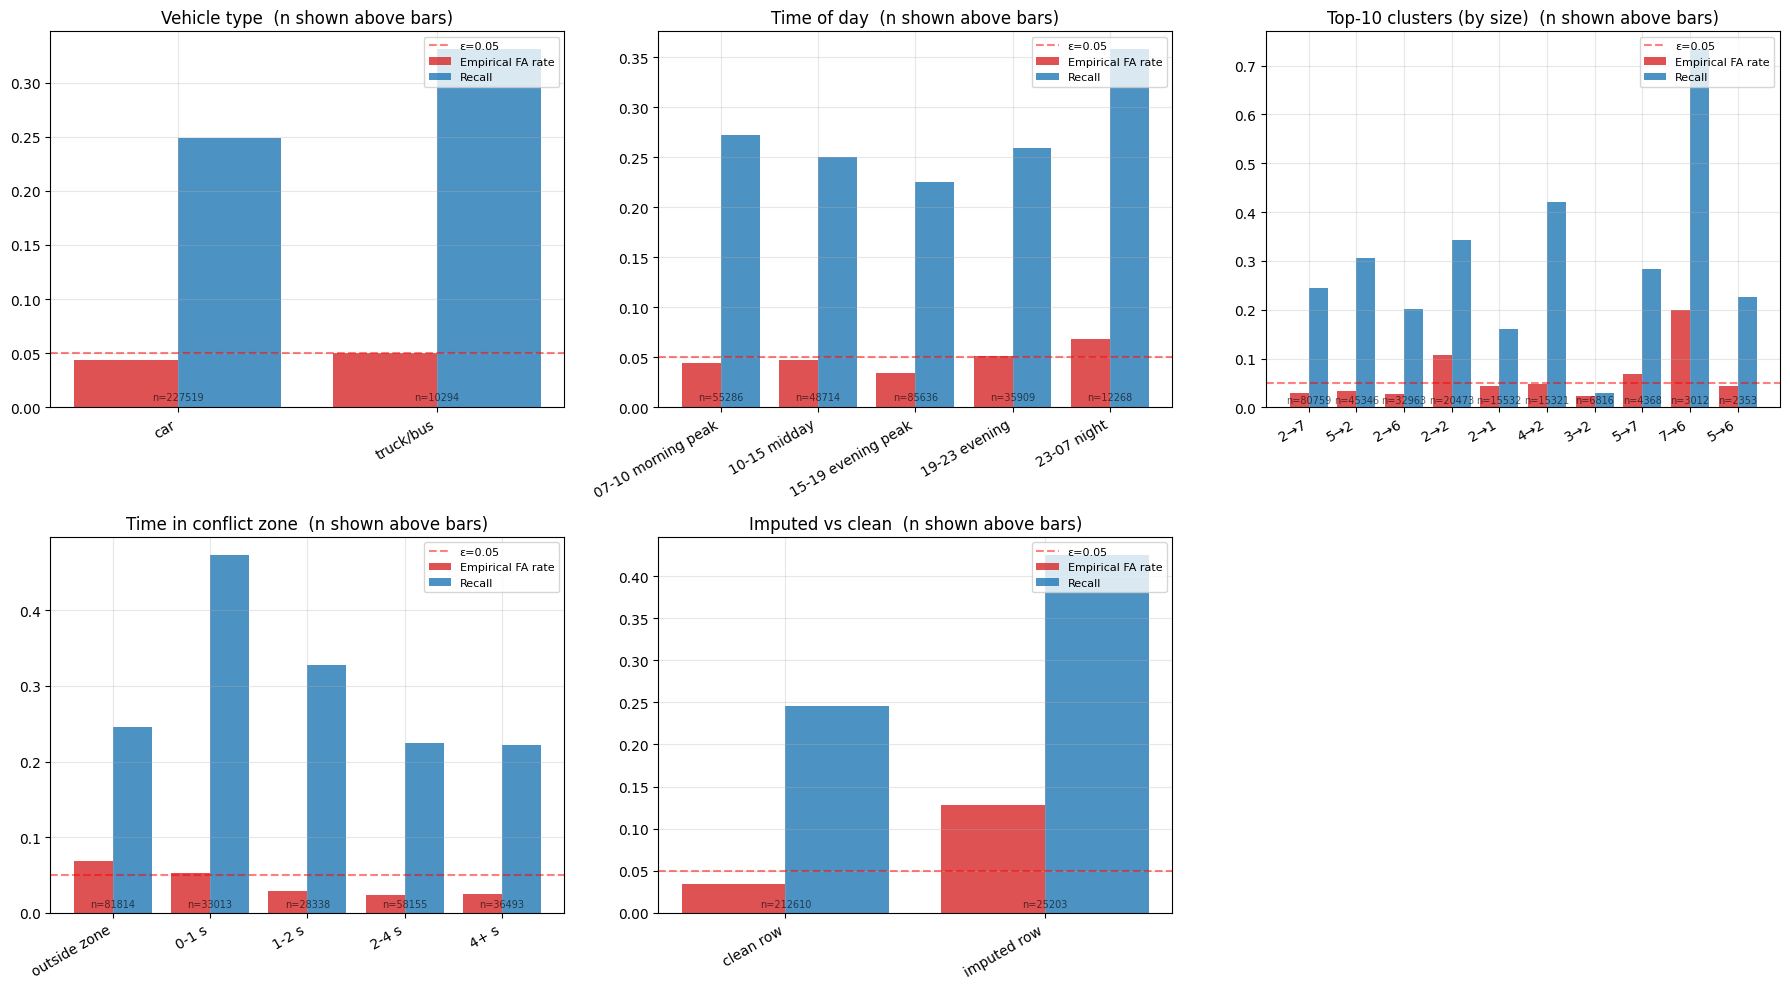

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

slices = [
    (tab_type, 'group', 'Vehicle type'),
    (tab_time, 'group', 'Time of day'),
    (tab_cluster.head(10), 'group', 'Top-10 clusters (by size)'),
    (tab_zone, 'group', 'Time in conflict zone'),
    (tab_imp, 'group', 'Imputed vs clean'),
]

for ax, (tab, key, title) in zip(axes[:5], slices):
    if len(tab) == 0:
        ax.set_title(f'{title}: no data'); continue
    x = np.arange(len(tab))
    w = 0.4
    ax.bar(x - w/2, tab['emp_FA_rate'], w, label='Empirical FA rate', color='tab:red', alpha=0.8)
    ax.bar(x + w/2, tab['recall'], w, label='Recall', color='tab:blue', alpha=0.8)
    ax.axhline(FIXED_EPS, color='red', linestyle='--', alpha=0.5, label=f'ε={FIXED_EPS}')
    ax.set_xticks(x)
    def _fmt(g):
        if isinstance(g, tuple):
            return '→'.join(str(int(v)) for v in g)
        return str(g)[:18]
    labels = [_fmt(g) for g in tab[key]]
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(f'{title}  (n shown above bars)')
    # Annotate sample sizes above bars so small subgroups are visually flagged
    for xi, n in zip(x, tab['n_rows']):
        ax.text(xi, 0.005, f'n={int(n)}', ha='center', va='bottom', fontsize=7, alpha=0.6)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[5].axis('off')

plt.tight_layout()
plt.savefig('bias_audit_plot.png', dpi=110)
plt.show()